In [15]:
%load_ext autoreload
%autoreload 2
import os
import sys
import trimesh
import fvdb
import argparse
from pprint import pprint
import tqdm
import h5py
from skimage import measure
from meshplot import plot
from scipy.spatial.distance import cdist
import joblib
import numpy as np
from scipy.spatial import KDTree
import igl
import fvdb.nn as fvnn

# Import ssu packages
sys.path.append('../src')
sys.path.append('../config')
# config packages
import read_config
# src packages
import eval
import utils
import models
from logger import wandb_logging
from data_loader import ABC_dataset_loader
from utils import fvdb_utils as fu
from utils import ssu_tools as st 
from utils import mesh_tools as mt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
gt_large =  '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
os.listdir(gt_large)
# read hdf5 file
import h5py
h5_file = h5py.File(os.path.join(gt_large, '00000028.hdf5'), 'r')
# print all keys
print(list(h5_file.keys()))
# read sdf
sdf_32 = h5_file['32_sdf'][:]
sdf_64 = h5_file['64_sdf'][:]
sdf_128 = h5_file['128_sdf'][:]
sdf_256 = h5_file['256_sdf'][:]
print(sdf_32.shape)
print(sdf_64.shape)
print(sdf_128.shape)
print(sdf_256.shape)

['128_sdf', '256_sdf', '32_sdf', '64_sdf']
(33, 33, 33)
(65, 65, 65)
(129, 129, 129)
(257, 257, 257)


In [17]:
# torch.randint(0, 7, 1)

In [18]:
import numpy as np
import torch
import fvdb
import fvdb.nn as fvnn
import mesh_tools as mt
from meshplot import plot

class sdfToVDB:
    def __init__(self, threshold = 33):
        self.threshold = threshold
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def vdb_marching_cubes(self, out: fvnn.VDBTensor):
        '''computes marching cubes for a VDBTensor'''
        nv, nf, _ = out.grid.marching_cubes(out.data)
        return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()
    
    def plot_vdb(self, 
                 out: fvnn.VDBTensor):
        '''plots a VDBTensor using mesh_tools'''
        nv, nf = self.vdb_marching_cubes(out)
        plot(nv, nf)

    def fetch_numpy_values(self, grid: fvdb.GridBatch, arr: np.array, size:int):
        '''fetches values from a numpy array based on the ijk indices in the grid'''
        ijk = grid.ijk.jdata.cpu().detach().numpy() + 16
        
        if max(ijk[:, 0]) >= arr.shape[0] or max(ijk[:, 1]) >= arr.shape[1] or max(ijk[:, 2]) >= arr.shape[2]:
            # If indices are out of bounds, we can add the maximum value to the indices
            ijk = np.clip(ijk, 0, np.array(arr.shape) - 1)
            # print(f"Indices out of bounds. Clipping to max shape: {arr.shape}")
        
        values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
        # values_sign = np.sign(values)
        # values_sign = torch.tensor(values_sign, dtype=torch.float32, device=grid.device)
        # values =  ((values + 1/65)/(1/65)) - 1
        # values = values / (self.threshold - 1)
        return torch.tensor(values, dtype=torch.float32, device=grid.device)

    
    def fetch_numpy_values_large(self, ijk, arr: np.array, size:int):
        '''fetches values from a numpy array based on the ijk indices in the grid'''
        ijk = ijk.cpu().detach().numpy()
        values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        return torch.tensor(values, dtype=torch.float32, device=device)

    def custom_subdivide_grid(self, grid: fvdb.GridBatch, scale, m3g, upsahpe):
        '''custom subdivision of a grid to create a finer grid:
            [0,    1,    2] -->
            [0, 1, 2, 3, 4]'''
        ijk = grid.ijk.jdata
        # m3g = torch.tensor(mt.mesh_grid(3),device=grid.device)-1
        new_ijk = (scale*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3)
        new_ijk = np.clip(new_ijk, 0, upsahpe-1)
        return fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), origins=grid.origins, voxel_sizes=grid.voxel_sizes/2)

    def scaled_sdf(self, sdf_arr: np.array):
        '''scales the SDF array by the threshold value'''
        return (self.threshold-1)*sdf_arr[:, None]
    
    def sdf_to_vdb(self,
                   sdf_arr: np.array, 
                   large_sdf_arr: np.array, 
                   mask: np.array, 
                   size=33,
                   is_test_set=False):
        '''Converts a SDF array to a VDBTensor with a given size and mask.'''

        #  create a grid of the size without nomalize actual shape
        ijk_mesh_grid = mt.mesh_grid(size)
        ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
        
        # consider only the points where the mask is True
        # normalize the ijk coordinates to be centered around (0, 0, 0)
        ijk = torch.tensor(ijk_mesh_grid[mask], 
                            dtype=torch.int, 
                            device=self.device)-16
        grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), 
                                        voxel_sizes=(1/(size-1)), 
                                        origins=torch.tensor([0, 0, 0], 
                                        device=self.device))
        
        sdf_values = self.fetch_numpy_values(grid, sdf_arr, size)
        sdf_values = self.scaled_sdf(sdf_values)
        # sdf_values = sdf_values[:, None] 
        
        # convert large sdf to vdb
        scale = 4
        m3g=torch.tensor(mt.mesh_grid(5), device=self.device)-2
        # upshape = 129
        # big_vdb_grid = self.custom_subdivide_grid(small_vdb.grid, 
        #                                           scale=scale, 
        #                                           m3g=m3g, 
        #                                           upsahpe=upshape)
        
        # Randomly select one coordinate from m3g for each element in grid.ijk.jdata
        if not is_test_set:
            num_elements = grid.ijk.jdata.shape[0]
            # random_indices = torch.randint(0, m3g.shape[0], (num_elements,), device=self.device)
            # random_indices = [random_indices[1]]*num_elements
            random_indices = np.random.randint(0, m3g.shape[0])
            selected_m3g = m3g[random_indices]  # Shape: (num_elements, 3)
            new_ijk = (scale * (grid.ijk.jdata+16)) + selected_m3g
            new_ijk_cpu = new_ijk.cpu().detach().numpy()
            new_ijk = np.clip(new_ijk_cpu, 0, large_sdf_arr.shape[0]-1)
            new_ijk = torch.tensor(new_ijk, dtype=torch.int, device=self.device)
            # print(large_sdf_arr.shape[0]-1)
            # print(new_ijk)
            # print(ijk)
            # print(grid.ijk.jdata+16)
            # print(selected_m3g)
            difference = new_ijk - (grid.ijk.jdata+16) * scale
            # print(difference)
            normalized_difference = difference/2
            # new_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), 
            #                                     origins=grid.origins, 
            #                                     voxel_sizes=grid.voxel_sizes)
            new_sdf_values = self.fetch_numpy_values_large(new_ijk, large_sdf_arr, 2*size-1)
            # print('sdf value \n',sdf_values)
            # print('new sdf values \n', new_sdf_values)
            # print(ijk.shape)
            # print(new_ijk.shape)
            new_sdf_values = self.scaled_sdf(new_sdf_values)
            # new_sdf_values = ((new_sdf_values - 1/65)/(1/65)) - 1
            # new_sdf_values = new_sdf_values[:, None]
            # print('new_sdf_values \n', new_sdf_values)

            large_vdb = fvnn.VDBTensor(grid, 
                                        grid.jagged_like(new_sdf_values))

            small_features = torch.cat([sdf_values, normalized_difference], dim=-1)
            # print(small_features) 
            small_vdb = fvnn.VDBTensor(grid, 
                                        grid.jagged_like(small_features))
        else:
            # For test set, we do not upscale the grid
            small_vdb = fvnn.VDBTensor(grid, 
                                        grid.jagged_like(sdf_values))
            new_ijk = ((scale * (grid.ijk.jdata+16)[:, None, :]) + m3g[None, :, :]).view(-1, 3)
            new_ijk_cpu = new_ijk.cpu().detach().numpy()
            new_ijk = np.clip(new_ijk_cpu, 0, large_sdf_arr.shape[0]-1)
            new_ijk = torch.tensor(new_ijk, dtype=torch.int, device=self.device)
            big_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), 
                                                origins=grid.origins, 
                                                voxel_sizes=grid.voxel_sizes)
            new_ijk = big_grid.ijk.jdata
            # print(new_ijk.shape)
            new_sdf_values = self.fetch_numpy_values_large(new_ijk, large_sdf_arr, 2*size-1)
            # print(new_sdf_values.shape)
            large_vdb = fvnn.VDBTensor(big_grid, 
                                        big_grid.jagged_like(new_sdf_values))
        return small_vdb, large_vdb
        

In [19]:
# Imports
import os
import sys
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm
import h5py
import joblib
import torch
import fvdb.nn as fvnn
import fvdb
import time

class ABCDataset(Dataset):
    def __init__(self, src_dir,
                 names_set,
                #  dataset_grids,
                #  mask_threshold, # in term grid size i,e grid size = 32 -> 3/32
                #  is_crop,
                #  crops_size,
                #  crops_size_probability,
                #  crops_threshold, 
                 max_tries=100, 
                 n_jobs=-1,
                 is_test_set=False):
        
        self.input_dir = src_dir
        self.names_set = names_set
        self.dataset_grids = [32, 128]
        self.mask_threshold = 65
        self.resolution_increase = 4

        self.is_crop = True
        self.crops_size = 16
        # self.crops_size_probability = crops_size_probability
        # self.crops_threshold = crops_threshold

        self.max_tries = max_tries
        self.n_jobs = n_jobs
        self.is_test_set = is_test_set

        # helping class
        self.sdfToVDB = sdfToVDB(threshold=self.mask_threshold)

        # stepup to read the dataset
        self._read_dataset()  # This will run setup() and read the files in parallel


    def _get_item(self, obj_name):
        '''Read the SDF in h5 file.'''

        sdf_dict = {}
        path = os.path.join(self.input_dir, obj_name)
        
        with h5py.File(path, 'r') as f:
            # check if the file has the required datasets
            if '32_sdf' not in f or '64_sdf' not in f or '128_sdf' not in f:
                raise ValueError(f"File {path} does not contain required datasets.")
            
            # fetch the SDF and output SDF
            sdf_dict['obj_name'] = obj_name
            for grid_size in self.dataset_grids:
                sdf_dict[grid_size+1] = f[f'{grid_size}_sdf'][:]

        return sdf_dict
    
    def _cropped_mask(self, mask):
        """
        Randomly crop a 3D array so that the crop contains at least n nonzero elements.
        crop_size: int or tuple (crop_x, crop_y, crop_z)
        threshold: minimum number of nonzero elements required in the crop
        max_tries: maximum number of attempts
        """

        # _crop_size = np.random.choice(self.crops_size, p=self.crops_size_probability)
        # _crop_size = int(_crop_size)
        _crop_size = self.crops_size
        if isinstance(_crop_size, int):
            crop_size = (_crop_size, _crop_size, _crop_size)
        sx, sy, sz = mask.shape
        cx, cy, cz = crop_size

        for _ in range(self.max_tries):
            x = np.random.randint(0, sx - cx + 1)
            y = np.random.randint(0, sy - cy + 1)
            z = np.random.randint(0, sz - cz + 1)
            
            crop = mask[x:x+cx, y:y+cy, z:z+cz]
            crop_threshold = 400

            if np.count_nonzero(crop) >= crop_threshold:
                mask_crop = np.zeros_like(mask, dtype=bool)
                mask_crop[x:x+cx, y:y+cy, z:z+cz] = crop
                return mask_crop
            
        # Ignore threshold - just return the crop
        print(f"Warning: Could not find a valid crop after {self.max_tries} attempts. Returning the last attempt.")
        mask_crop = np.zeros_like(mask, dtype=bool)
        mask_crop[x:x+cx, y:y+cy, z:z+cz] = crop
        return mask_crop

    def _read_dataset(self):
        out = joblib.Parallel(n_jobs=self.n_jobs)(joblib.delayed(self._get_item)
                                                (obj_name) for obj_name in tqdm(self.names_set))

        # check for empty set
        if len(out) == 0:
            raise ValueError("No valid SDF data found in the provided dataset.")
        
        # mask SDFs of 32
        self.mask_32 = [mt.make_mask_close(_dict[33], self.mask_threshold)  for _dict in out]
        self.out = out

    def _get_vdb_from_sdf(self, index):
        _dict = self.out[index]

        # create a set to hold the vdb tensors
        vdb_set = []
        vdb_set.append(_dict['obj_name'])

        # crop mask SDFs of 32
        mask_32_index = self.mask_32[index]
        # if self.is_crop:
        #     mask_32_index = self._cropped_mask(mask_32_index)

        input_vdb, output_vdb = self.sdfToVDB.sdf_to_vdb(_dict[33],
                                                        _dict[129],
                                                        mask_32_index,
                                                        size=33,
                                                        is_test_set=self.is_test_set)

        # add the input vdb to the set
        vdb_set.append(input_vdb)

        vdb_set.append(output_vdb)                                 

        return tuple(vdb_set)

    def __len__(self):
        return len(self.out)
    
    def __getitem__(self, index):
        return self._get_vdb_from_sdf(index)


class ABCDataLoader():
    def __init__(self, 
                 input_dir, 
                 config,
                 n_samples=None):
        self.input_dir = input_dir
        self.config = config
        self.n_samples = n_samples

    @staticmethod
    def custom_collate_fn(batch):
        # batch is a list of tuples: [(vdb_32, vdb_64, vdb_128), ...]
        # level 2: 32 -> 64
        # level 3: 32 -> 64 -> 128
        # level 4: 32 -> 64 -> 128 -> 256
        level = len(batch[0])-1 # -1 because first element is obj_name
        if level == 2:
            obj_names, vdb_32s, vdb_64s = zip(*batch)
            return list(obj_names), list(vdb_32s), list(vdb_64s)
        elif level == 3:
            obj_names, vdb_32s, vdb_64s, vdb_128s = zip(*batch)
            return list(obj_names), list(vdb_32s), list(vdb_64s), list(vdb_128s)
        elif level == 4:
            obj_names, vdb_32s, vdb_64s, vdb_128s, vdb_256s = zip(*batch)
            return list(obj_names), list(vdb_32s), list(vdb_64s), list(vdb_128s), list(vdb_256s)
        else:
            raise ValueError(f"Unsupported upscaling: workable upscaling are 64, 128, 256, not above 256")

    def get_vdb_data_loaders(self,
                             train_dataset,
                             val_dataset,
                             test_dataset, 
                             batch_size=1, 
                             shuffle=None, 
                             num_workers=0):
        
        is_eval = False  # This can be set based on your evaluation mode
        if not is_eval:
            train_dataloader =  torch.utils.data.DataLoader(train_dataset, 
                                                collate_fn=self.custom_collate_fn,
                                                batch_size=batch_size, 
                                                shuffle=True, 
                                                num_workers=num_workers)
            val_dataloader = torch.utils.data.DataLoader(val_dataset,
                                                collate_fn=self.custom_collate_fn,
                                                batch_size=batch_size,
                                                shuffle=True, 
                                                num_workers=num_workers)
        else:
            train_dataloader = None
            val_dataloader = None

        test_dataloader = torch.utils.data.DataLoader(test_dataset,
                                            collate_fn=self.custom_collate_fn,
                                            # batch_size=batch_size,
                                            batch_size=1,  # Test loader usually has batch size of 1
                                            shuffle=False, 
                                            num_workers=num_workers)
        return train_dataloader, val_dataloader, test_dataloader


    def split_dataset(self,
                      names_set, 
                      train_ratio=0.6, 
                      val_ratio=0.2):
        """
        Splits the dataset into train, validation, and test sets.
        """
        total_size = len(names_set)
        train_size = int(total_size * train_ratio)
        val_size = int(total_size * val_ratio)

        np.random.shuffle(names_set)
        train_set = names_set[:train_size]
        val_set = names_set[train_size:train_size + val_size]
        test_set = names_set[train_size + val_size:]

        print(f"Dataset split: {len(train_set)} train, {len(val_set)} val, {len(test_set)} test")

        return train_set, val_set, test_set

    
    def get(self, names_set):
        if self.n_samples is not None:
            if not isinstance(self.n_samples, int):
                raise ValueError("n_samples must be an integer or None")
            names_set = names_set[:self.n_samples]

        train_set, val_set, test_set = self.split_dataset(names_set, 
                                        train_ratio=0.6, 
                                        val_ratio=0.2)
        
        is_eval = False
        if not is_eval:
            train_dataset = ABCDataset(
                src_dir=self.input_dir,
                names_set=train_set,
                # dataset_grids=self.config['data']['dataset_grids'],
                # mask_threshold=self.config['data']['mask_threshold'],
                # is_crop=self.config['data']['is_crop']['train'],
                # crops_size=self.config['data']['crops_size'],
                # crops_size_probability=self.config['data']['crops_size_probability'],
                # crops_threshold=self.config['data']['crops_threshold'],
                n_jobs=-1
            )
            val_dataset = ABCDataset(
                src_dir=self.input_dir,
                names_set=val_set,
                # dataset_grids=self.config['data']['dataset_grids'],
                # mask_threshold=self.config['data']['mask_threshold'],
                # is_crop=self.config['data']['is_crop']['val'],
                # crops_size=self.config['data']['crops_size'],
                # crops_size_probability=self.config['data']['crops_size_probability'],
                # crops_threshold=self.config['data']['crops_threshold'],
                n_jobs=-1
            )
        else:
            train_dataset = None
            val_dataset = None
            
        test_dataset = ABCDataset(
            src_dir=self.input_dir,
            names_set=test_set,
            # dataset_grids=self.config['data']['dataset_grids'],
            # mask_threshold=self.config['data']['mask_threshold'],
            # is_crop=self.config['data']['is_crop']['test'],
            # crops_size=self.config['data']['crops_size'],
            # crops_size_probability=self.config['data']['crops_size_probability'],
            # crops_threshold=self.config['data']['crops_threshold'],
            n_jobs=-1,
            # is_test_set=True
        )
        
        train_dataloader, val_dataloader, test_dataloader = self.get_vdb_data_loaders(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            test_dataset=test_dataset,
            batch_size=16,
            shuffle=True,
            num_workers=0
        )
        return train_dataloader, val_dataloader, test_dataloader

In [20]:
# redproducibility
import random
def set_reproducibility(is_reproducible=True, seed=42):
    if is_reproducible:
        print(f"Setting reproducibility with seed: {seed}")
        random.seed(seed)
        np.random.seed(seed)
        try:
            torch.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        except ImportError:
            pass
    else:
        print("Reproducibility is not set. Random seeds will not be fixed.")


In [21]:
# load data
import random
# random.seed(42)
set_reproducibility(is_reproducible=True, seed=42)
input_dir = '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
names_set = os.listdir('/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large')
(train_dataloader, 
val_dataloader, 
test_dataloader) = ABCDataLoader(
                                    input_dir=input_dir,
                                    config={},
                                    n_samples=10
                                ).get(names_set=names_set)

Setting reproducibility with seed: 42
Dataset split: 6 train, 2 val, 2 test


100%|██████████| 6/6 [00:00<00:00, 5426.01it/s]


100%|██████████| 2/2 [00:00<00:00, 1242.20it/s]


In [22]:
# get one value from the dataloader
for batch in train_dataloader:
    obj_names, vdb_32s, vdb_64s = batch
    print(f"Object names: {obj_names}")
    print(f"VDB 32 shape: {vdb_32s[0].jdata.shape}")
    print(f"VDB 64 shape: {vdb_64s[0].jdata.shape}")
    

Object names: ['00000006.hdf5', '00000003.hdf5', '00000026.hdf5', '00000018.hdf5', '00000007.hdf5', '00000020.hdf5']
VDB 32 shape: torch.Size([3410, 4])
VDB 64 shape: torch.Size([3410, 1])


In [8]:
import torch
import torch.nn as nn
import fvdb.nn as fvnn

class CNN_vanilla(nn.Module):
    def __init__(self, in_channels=3, features=32, out_channels=1, dropout=0.05):
        super(CNN_vanilla, self).__init__()
        
        self.activation = fvnn.SiLU(inplace=True)
        self.encoder = nn.Sequential(
            fvnn.SparseConv3d(in_channels, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,

            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation
        )
        
        self.decoder = nn.Sequential(
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, out_channels, kernel_size=3, stride=1)
        )

        self.t_conv = fvnn.SparseConv3d(
            features, features, kernel_size=3, stride=2, transposed=True) #TODO check that this is correct

    def forward(self, x):
        enc = self.encoder(x)
        # x = self.t_conv(enc, out_grid=out_grid)
        # input_sdf = fvnn.VDBTensor(x.grid, x.grid.jagged_like(x.jdata[:, 0].unsqueeze(-1)))
        return self.decoder(enc)

In [9]:
from models import unet as simpleModels
# simpleModels.FVDBUNetBase
model = CNN_vanilla(
    in_channels=5,
    out_channels=1)
trainable_params = st.print_model_summary(model)

Total parameters: 198977
Trainable parameters: 198977


In [10]:
optimizer = torch.optim.Adam(model.parameters(), 
                            lr=0.001, 
                            # weight_decay=1e-5
                            )

In [11]:
sys.path.append('../flow_matching')
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
# from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

In [12]:
import os
import sys
import fvdb
import torch
import wandb
from tqdm import tqdm
from training.loss import LossFunctions

class ModelTrainer:
    def __init__(self,
                 model_name, 
                 model, 
                 num_epochs,
                 train_loader, 
                 val_loader,
                #  test_loader,
                #  pos_enc_dim, 
                 optimizer, 
                 loss_fn_name,
                #  loss_weights,
                #  is_save_model,
                #  save_model_dir, 
                #  logger
                 ):
        
        self.model_name = model_name
        self.model = model
        self.num_epochs = num_epochs

        self.train_loader = train_loader
        self.val_loader = val_loader
        # self.test_loader = test_loader
        # self.pos_enc_dim = pos_enc_dim

        self.optimizer = optimizer
        self.loss_fn = loss_fn_name
        self.loss_fn = LossFunctions(loss_fn_name).loss_fn
        # self.loss_weights = loss_weights
        
        # self.is_save_model = is_save_model
        # self.save_model_dir = save_model_dir
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model.to(self.device)

        # self.logger = logger
        # self.logger.log({'loss_weights': wandb.Table(data=[self.loss_weights], 
                                                    #  columns=['w1', 'w2', 'w3'])})

    def train_sub_step(self, inputs):
        # inputs = positional_encoding(inputs, self.pos_enc_dim)

        outputs = self.model(inputs)
        return outputs

    def append_feature(self, input_vdbs, feature):
        concat_features = torch.cat([input_vdbs.jdata, feature], dim=-1)
        return fvnn.VDBTensor(input_vdbs.grid, input_vdbs.grid.jagged_like(concat_features))

    def sample_fm(self, input_vdbs, output_vdbs):
        t = torch.rand_like(output_vdbs.jdata, device=self.device)
        # print(t.shape, input_vdbs.jdata[:, 0].shape, )
        features = t * input_vdbs.jdata[:, 0].unsqueeze(1) + (1 - t) * output_vdbs.jdata
        features = torch.cat([features, input_vdbs.jdata[:, 1:], t], dim=-1)
        # print(features.shape)
        sampled_vdbs = fvnn.VDBTensor(input_vdbs.grid,
                                      input_vdbs.grid.jagged_like(features))
        return sampled_vdbs

    def velocity_fm(self, input_vdbs, output_vdbs):
        velocity = output_vdbs.jdata[:, 0] - input_vdbs.jdata[:, 0]
        velocity_vdb = fvnn.VDBTensor(input_vdbs.grid,
                                  input_vdbs.grid.jagged_like(velocity[:, None]))
        return velocity_vdb
    
    def eval_fm_steps(self, input_vdbs, model, n_steps=4):
        dt = 1 / n_steps
        t = torch.full_like(input_vdbs.jdata[:, 0], 0).to(self.device)
        t = t.unsqueeze(1)  # Ensure t is a column vector
        input_vdbs = self.append_feature(input_vdbs, t)
        for t in range(n_steps):
            t = torch.full_like(input_vdbs.jdata[:, 0], t/n_steps).to(self.device)
            # t = t.unsqueeze(1)  # Ensure t is a column vector
            input_vdbs.jdata[:, -1] = t
            updated_sdf = input_vdbs.jdata[:, 0].unsqueeze(1) + dt * model(input_vdbs).jdata
            input_vdbs.jdata[:, 0] = updated_sdf.squeeze(1)
            # print(input_vdbs.jdata.shape)
            input_vdbs = fvnn.VDBTensor(input_vdbs.grid,
                                        input_vdbs.grid.jagged_like(
                                            input_vdbs.jdata
                                        ))
            
        predicted_vdbs = fvnn.VDBTensor(input_vdbs.grid,
                                        input_vdbs.grid.jagged_like(
                                            input_vdbs.jdata[:, 0].unsqueeze(1)
                                        ))
        return predicted_vdbs

    def train(self):
        min_val_loss = float('inf')
        for epoch in range(self.num_epochs):
            self.model.train()
            total_loss = 0
            # avg_loss_1 = 0
            # avg_loss_2 = 0
            # avg_loss_3 = 0
            for batch in tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.num_epochs}'):
                obj_names, vdb_input, vdb_output = batch
                # print(vdb_input[0].jdata.shape)
                vdb_inputs = fvdb.jcat(vdb_input)
                vdb_outputs = fvdb.jcat(vdb_output)
                self.optimizer.zero_grad()

                # xt = self.sample_fm(vdb_inputs, vdb_outputs)
                # velocity = self.velocity_fm(vdb_inputs, vdb_outputs)
                path = AffineProbPath(scheduler=CondOTScheduler())
                t = torch.rand(vdb_outputs.jdata.shape[0]).to(self.device)
                path_sample = path.sample(t=t, 
                                          x_0=vdb_inputs.jdata[:,0], 
                                          x_1=vdb_outputs.jdata[:,0])
                xt = path_sample.x_t
                t = path_sample.t
                velocity = path_sample.dx_t

                xt_feature = torch.cat([xt.unsqueeze(1), 
                                        vdb_inputs.jdata[:, 1:], 
                                        t.unsqueeze(1)], dim=-1)
                xt = fvnn.VDBTensor(vdb_inputs.grid,
                                    vdb_inputs.grid.jagged_like(xt_feature))
                velocity = fvnn.VDBTensor(vdb_inputs.grid,
                                          vdb_inputs.grid.jagged_like(velocity[:, None]))
                preds = self.train_sub_step(xt)

                # Compute losses for each output and target
                loss = self.loss_fn(preds.jdata, velocity.jdata)

                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
            avg_loss = total_loss / len(self.train_loader)
            print(f"Epoch {epoch+1}/{self.num_epochs}, Loss: {avg_loss:.4f}")
            if self.val_loader:
                (avg_val_loss) = self.validation()
            
            # Log the training loss
            # self.logger.log({
            #     'train_loss': avg_loss,
            #     'train_loss_32->64': avg_loss_1,
            #     'train_loss_64->128': avg_loss_2,
            #     'train_loss_32->64->128': avg_val_loss_3,
            #     'val_loss': avg_val_loss,
            #     'val_loss_32->64': avg_val_loss_1,
            #     'val_loss_64->128': avg_val_loss_2,
            #     'val_loss_32->64->128': avg_val_loss_3,
            #     'epoch': epoch + 1
            # })
            
            # Check if validation loss is lower than the minimum recorded loss
            if avg_val_loss < min_val_loss:
                min_val_loss = avg_val_loss
                # if self.is_save_model:
                #     self.save_model()
        
        print(f"Training complete. Minimum validation loss: {min_val_loss:.4f}")
        
    def validation(self):
        self.model.eval()
        total_loss = 0
        # avg_loss_1 = 0
        # avg_loss_2 = 0
        # avg_loss_3 = 0
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='Validation'):
                obj_names, vdb_input, vdb_output = batch
                vdb_inputs = fvdb.jcat(vdb_input)
                vdb_outputs = fvdb.jcat(vdb_output)

                # preds = self.train_sub_step(vdb_inputs)
                preds = self.eval_fm_steps(vdb_inputs, self.model, n_steps=4)

                loss = self.loss_fn(preds.jdata, vdb_outputs.jdata)

                total_loss += loss.item()
                
        avg_loss = total_loss / len(self.val_loader)
        print(f"Validation Loss: {avg_loss:.4f}")
        return avg_loss

    # def save_model(self):
    #     path = os.path.join(self.save_model_dir, f"{self.model_name}.pth")
    #     torch.save(self.model, path)
    #     print(f"Model saved to {path}")



In [13]:
trainer = ModelTrainer(
    model_name='CNN_vanilla',
    model=model,
    num_epochs=20,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    # test_loader=test_dataloader,
    optimizer=optimizer,
    loss_fn_name='mse_loss')
trainer.train()

Epoch 1/20: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


Epoch 1/20, Loss: 0.5781


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.49it/s]


Validation Loss: 0.3636


Epoch 2/20: 100%|██████████| 1/1 [00:00<00:00,  2.79it/s]


...

Validation Loss: 0.3942


Epoch 20/20: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


Epoch 20/20, Loss: 0.5222


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.47it/s]

Validation Loss: 0.4645
Training complete. Minimum validation loss: 0.2926


In [14]:
# 0.0876
# 0.0258

In [107]:
model =  torch.load('/data/workspaces/spanwar/results/ssu/save_models/66_test_weighted_loss_e_1.pth')
model = model.to('cuda')
model.eval()

/tmp/ipykernel_692860/3054902418.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model =  torch.load('/data/workspaces/spanwar/results/ssu/save_models/66_test_weighted_l

FVDBUNetBase(
  (conv0p1s1): SparseConv3d(5, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=

In [108]:
# Create a shuffled version of the test dataloader to get different first values
import torch.utils.data as data
import random

# Method 1: Create new shuffled dataloader from existing dataset
def create_shuffled_dataloader(original_dataloader):
    dataset = original_dataloader.dataset
    
    # Create shuffled indices
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    
    # Create subset with shuffled indices
    shuffled_dataset = data.Subset(dataset, indices)
    
    # Create new dataloader with same parameters but shuffled data
    shuffled_dataloader = data.DataLoader(
        shuffled_dataset,
        batch_size=original_dataloader.batch_size,
        shuffle=False,  # Don't shuffle again since we already shuffled indices
        num_workers=original_dataloader.num_workers,
        collate_fn=original_dataloader.collate_fn
    )
    
    return shuffled_dataloader

In [109]:
def get_new_positions(vdb_tensor, upscale_factor=8):
    m3g = torch.tensor(mt.mesh_grid(upscale_factor+1), device=vdb_tensor.device) - (upscale_factor // 2)
    m3g_vector = m3g/2
    ijks = []
    new_features = []
    all_ijk = set()
    for mg, mg_vector in zip(m3g, m3g_vector):
        ijk = vdb_tensor.grid.ijk.jdata + 16
        ijk = (upscale_factor * ijk + mg).view(-1, 3)
        ijk = np.clip(ijk.cpu().detach().numpy(), 0, (upscale_factor * 32))
        
        # # Unique ijk positions: remove ijk that exist in all_ijk
        # ijk = [pos for pos in ijk if tuple(pos) not in all_ijk]
        # all_ijk.update(map(tuple, ijk.cpu().detach().numpy()))
    
        ijk_vector = ijk - (vdb_tensor.grid.ijk.jdata.cpu().detach().numpy()+16) * upscale_factor
        ijk_vector = ijk_vector / (upscale_factor//2)  # Normalize the vector
        ijk_vector = torch.tensor(ijk_vector, dtype=torch.float32, device=vdb_tensor.device)

        new_features.append(torch.cat([vdb_tensor.data.jdata[:, 0][:, None], ijk_vector], axis=-1))
        ijks.append(torch.tensor(ijk, dtype=torch.int, device=vdb_tensor.device))
    return new_features, ijks

In [156]:
def eval_fm_steps(input_vdbs, model, n_steps=4):
    def append_feature(input_vdbs, feature):
        concat_features = torch.cat([input_vdbs.jdata, feature], dim=-1)
        return fvnn.VDBTensor(input_vdbs.grid, input_vdbs.grid.jagged_like(concat_features))
    dt = 1 / n_steps
    t = torch.full_like(input_vdbs.jdata[:, 0], 0).to(input_vdbs.device)
    t = t.unsqueeze(1)  # Ensure t is a column vector
    input_vdbs = append_feature(input_vdbs, t)
    for t in range(n_steps):
        actual_t = t
        # print(f"Step {t/n_steps}")
        t = torch.full_like(input_vdbs.jdata[:, 0], t/n_steps).to(input_vdbs.device)
        # t = t.unsqueeze(1)  # Ensure t is a column vector
        input_vdbs.jdata[:, -1] = t
        updated_sdf = input_vdbs.jdata[:, 0].unsqueeze(1) + dt * model(input_vdbs).jdata
        input_vdbs.jdata[:, 0] = updated_sdf.squeeze(1)
        # print(input_vdbs.jdata.shape)
        input_vdbs = fvnn.VDBTensor(input_vdbs.grid,
                                    input_vdbs.grid.jagged_like(
                                        input_vdbs.jdata
                                    ))
        # print(actual_t)
        if actual_t+1 == 8:
            print(actual_t)
            predicted_vdbs = fvnn.VDBTensor(input_vdbs.grid,
                                            input_vdbs.grid.jagged_like(
                                                input_vdbs.jdata[:, 0].unsqueeze(1)
                                            ))
            return predicted_vdbs

In [157]:
# def eval_fm_steps(input_vdbs, model, n_steps=4):
#     """
#     Midpoint (RK2) integrator over time t in [0, 1], updating ONLY the first channel (SDF).
#     Assumes:
#       - input_vdbs.jdata shape = [num_samples, C]
#       - channel 0 is the scalar SDF value we integrate
#       - we will append a time feature t as the LAST channel
#       - model(input_vdbs) returns a VDBTensor with .jdata shaped [num_samples, 1] (dSDF/dt)
#     """
#     def append_feature(vdb, feature_col):
#         concat = torch.cat([vdb.jdata, feature_col], dim=-1)
#         return fvnn.VDBTensor(vdb.grid, vdb.grid.jagged_like(concat))

#     def replace_jdata(vdb, new_jdata):
#         # Re-wrap to keep jagged layout correct
#         return fvnn.VDBTensor(vdb.grid, vdb.grid.jagged_like(new_jdata))

#     device = input_vdbs.jdata.device
#     dtype  = input_vdbs.jdata.dtype

#     # Time setup
#     dt = 1.0 / n_steps
#     # Create t column (start at 0). Make it 2D so concat works: [N,1]
#     t_col = torch.zeros((input_vdbs.jdata.shape[0], 1), device=device, dtype=dtype)

#     # Append time as LAST channel
#     vdb = append_feature(input_vdbs, t_col)

#     for step in range(n_steps):
#         # Current time as scalar and as column
#         t_scalar = step * dt
#         t_curr = torch.full_like(t_col, t_scalar)

#         # Set t in-place as LAST channel
#         vdb_j = vdb.jdata
#         vdb_j[:, -1] = t_curr.squeeze(-1)
#         vdb = replace_jdata(vdb, vdb_j)

#         # ---- k1 at (x, t) ----
#         # Take current SDF values
#         x_curr = vdb.jdata[:, 0:1]  # [N,1]
#         k1 = model(vdb).jdata       # [N,1]  -> dSDF/dt

#         # ---- midpoint state ----
#         x_mid = x_curr + 0.5 * dt * k1
#         t_mid = t_scalar + 0.5 * dt

#         # Build a temp VDBTensor with SDF replaced by x_mid and time set to t_mid
#         vdb_mid_j = vdb.jdata.clone()
#         vdb_mid_j[:, 0] = x_mid.squeeze(-1)            # replace SDF channel with midpoint guess
#         vdb_mid_j[:, -1] = t_mid                       # set time to midpoint
#         vdb_mid = replace_jdata(vdb, vdb_mid_j)

#         # ---- k2 at (x_mid, t_mid) ----
#         k2 = model(vdb_mid).jdata  # [N,1]

#         # ---- final update ----
#         x_next = x_curr + dt * k2

#         # Write back updated SDF into vdb
#         vdb_next_j = vdb.jdata.clone()
#         vdb_next_j[:, 0] = x_next.squeeze(-1)
#         vdb = replace_jdata(vdb, vdb_next_j)

#     # Return only the predicted SDF channel as a VDBTensor with single channel
#     out = fvnn.VDBTensor(
#         vdb.grid,
#         vdb.grid.jagged_like(vdb.jdata[:, 0:1])
#     )
#     return out


In [158]:
import torch
import gc

def clear_gpu_memory():
    """Clear all GPU memory allocated by PyTorch"""
    
    if torch.cuda.is_available():
        # Clear PyTorch cache
        torch.cuda.empty_cache()
        
        # Force garbage collection
        gc.collect()
        
        # Clear all tensors from GPU
        torch.cuda.synchronize()
        
        # Get memory info
        allocated = torch.cuda.memory_allocated() / 1e9
        cached = torch.cuda.memory_reserved() / 1e9
        
        print(f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB")
        
        # If memory is still allocated, try more aggressive clearing
        if allocated > 0:
            print("Attempting to clear more GPU memory...")
            print("Avoiding this step")
            # torch.cuda.empty_cache()
            # torch.cuda.synchronize()
            # gc.collect()
            
        print("✅ GPU memory cleared")
    else:
        print("❌ No CUDA GPU available")

# Call this function
clear_gpu_memory()

GPU Memory - Allocated: 2.48 GB, Cached: 2.76 GB
Attempting to clear more GPU memory...
Avoiding this step
✅ GPU memory cleared


In [159]:
# import time
# # test_dataloader = create_shuffled_dataloader(test_dataloader)
# # train_dataloader = create_shuffled_dataloader(train_dataloader)

# def produce_results(model, test_loader, upscale_factor=4):
#     model.eval()
#     results = []
#     with torch.no_grad():
#         for batch in tqdm(test_loader, desc='Testing'):
#             obj_names, vdb_input, _ = batch
#             # if '00001937.hdf5' not in obj_names:
#             #     continue
#             # else:
#             #     index = obj_names.index('00001937.hdf5')
#             #     print(f"Processing object: {obj_names[index]}")
#             #     vdb_input = [vdb_input[index]]
#             # actual_sdf = h5py.File(os.path.join(gt_large, obj_names[0]), 'r')['128_sdf'][:]
#             for vdb_tensor in vdb_input:
#                 sub_vdb_tensor = []
#                 upscale_shape = (upscale_factor * 32 + 1, upscale_factor * 32 + 1, upscale_factor * 32 + 1)
#                 # sdf = np.full((257, 257, 257), 100.0)
#                 sdf = np.full(upscale_shape, 100.0)
#                 # sdf = actual_sdf.copy()
#                 start = time.time()
#                 new_features, ijks = get_new_positions(vdb_tensor, upscale_factor=upscale_factor)
#                 new_vdb_tensors = []
#                 for new_feature, ijk in zip(new_features, ijks):
#                     new_vdb_tensors.append(fvnn.VDBTensor(vdb_tensor.grid,
#                         vdb_tensor.grid.jagged_like(new_feature)
#                     ))
#                 end = time.time()
#                 print(f"Time taken to create new VDB tensors: {end - start:.2f} seconds")
#                 start = time.time()
#                 new_vdb_tensors = fvdb.jcat(new_vdb_tensors)
#                 preds = eval_fm_steps(new_vdb_tensors, model, 10)
#                 print(f"Preds shape: {preds.jdata.shape}")
#                 print(f"ijk shape: {preds.grid.ijk.jdata.shape}")
#                 print(f"ijk: {ijk.shape}")
#                 pred_ijk = preds.grid.ijk.jdata.cpu().detach().numpy()
#                 pred_values = preds.jdata.detach().cpu().numpy().squeeze()  # Remove extra dimension
#                 vector = new_vdb_tensors.jdata[:, 1:4].cpu().detach().numpy()  
#                 pred_ijk = (pred_ijk+16)*upscale_factor + (vector*(upscale_factor//2)).astype(int)
#                 print(f"Pred values: {pred_values.shape}")
#                 print(f"Pred ijk: {pred_ijk.shape}")
#                 # print(pred.jdata.shape)
#                 # ijk = ijk.jdata.cpu().detach().numpy()
#                 # ijk = ijk.cpu().detach().numpy()
#                 # pred_values = preds.jdata.cpu().detach().numpy().squeeze()  # Remove extra dimension
#                 # print(pred_values)
#                 # print(pred_values.shape)
#                 sdf[pred_ijk[:, 0], pred_ijk[:, 1], pred_ijk[:, 2]] = pred_values
#                 end = time.time()
#                 print(f"Time taken for eval_fm_steps: {end - start:.2f} seconds")
                
#                 sdf_mask = np.abs(sdf) < 100

#                 # create a fvdb tensor from the sdf
#                 grid = fvdb.gridbatch_from_ijk(
#                         fvdb.JaggedTensor(torch.tensor(np.array(np.where(sdf_mask)).T)),
#                         voxel_sizes=(1/128),
#                         origins=torch.tensor([0, 0, 0])
#                     )
#                 new_ijk = grid.ijk.jdata.cpu().detach().numpy()
#                 values = sdf[new_ijk[:, 0], new_ijk[:, 1], new_ijk[:, 2]]
#                 sdf_tensor = fvnn.VDBTensor(
#                     grid,
#                     grid.jagged_like(torch.tensor(values))
#                 )
#                 results.append({
#                     'obj_name': obj_names[0],
#                     'sdf': sdf,
#                     'sdf_tensor': sdf_tensor,
#                 })
#             return results
# results = produce_results(model, train_dataloader, upscale_factor=4)

In [160]:
import time
# test_dataloader = create_shuffled_dataloader(test_dataloader)
# train_dataloader = create_shuffled_dataloader(train_dataloader)

def produce_results(model, test_loader, upscale_factor=4):
    model.eval()
    results = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Testing'):
            obj_names, vdb_input, _ = batch
            # if '00001937.hdf5' not in obj_names:
            #     continue
            # else:
            #     index = obj_names.index('00001937.hdf5')
            #     print(f"Processing object: {obj_names[index]}")
            #     vdb_input = [vdb_input[index]]
            # actual_sdf = h5py.File(os.path.join(gt_large, obj_names[0]), 'r')['128_sdf'][:]
            for vdb_tensor in vdb_input:
                sub_vdb_tensor = []
                upscale_shape = (upscale_factor * 32 + 1, upscale_factor * 32 + 1, upscale_factor * 32 + 1)
                # sdf = np.full((257, 257, 257), 100.0)
                sdf = np.full(upscale_shape, 100.0)
                # sdf = actual_sdf.copy()
                start = time.time()
                new_features, ijks = get_new_positions(vdb_tensor, upscale_factor=upscale_factor)
                new_vdb_tensors = []
                for new_feature, ijk in zip(new_features, ijks):
                    new_vdb_tensors.append(fvnn.VDBTensor(vdb_tensor.grid,
                        vdb_tensor.grid.jagged_like(new_feature)
                    ))
                end = time.time()
                print(f"Time taken to create new VDB tensors: {end - start:.2f} seconds")
                start = time.time()
                new_vdb_tensors = fvdb.jcat(new_vdb_tensors)
                preds = eval_fm_steps(new_vdb_tensors, model, 10)
                print(f"Preds shape: {preds.jdata.shape}")
                print(f"ijk shape: {preds.grid.ijk.jdata.shape}")
                print(f"ijk: {ijk.shape}")
                pred_ijk = preds.grid.ijk.jdata.cpu().detach().numpy()
                pred_values = preds.jdata.detach().cpu().numpy().squeeze()  # Remove extra dimension
                vector = new_vdb_tensors.jdata[:, 1:4].cpu().detach().numpy()  
                pred_ijk = (pred_ijk+16)*upscale_factor + (vector*(upscale_factor//2)).astype(int)
                print(f"Pred values: {pred_values.shape}")
                print(f"Pred ijk: {pred_ijk.shape}")
                # print(pred.jdata.shape)
                # ijk = ijk.jdata.cpu().detach().numpy()
                # ijk = ijk.cpu().detach().numpy()
                # pred_values = preds.jdata.cpu().detach().numpy().squeeze()  # Remove extra dimension
                # print(pred_values)
                # print(pred_values.shape)
                sdf[pred_ijk[:, 0], pred_ijk[:, 1], pred_ijk[:, 2]] = pred_values
                # means predictions
                D, H, W = sdf.shape
                flat_idx = np.ravel_multi_index(pred_ijk.T, sdf.shape)  # (N,)

                sum_arr = np.zeros(sdf.size, dtype=np.float32)
                cnt_arr = np.zeros(sdf.size, dtype=np.int64)

                np.add.at(sum_arr, flat_idx, pred_values)     # accumulate sums per voxel
                np.add.at(cnt_arr, flat_idx, 1)               # accumulate counts per voxel

                mask = cnt_arr > 0
                mean_arr = np.zeros_like(sum_arr, dtype=np.float32)
                mean_arr[mask] = sum_arr[mask] / cnt_arr[mask]

                sdf.flat[mask] = mean_arr[mask] 
                end = time.time()
                print(f"Time taken for eval_fm_steps: {end - start:.2f} seconds")
                
                sdf_mask = np.abs(sdf) < 100

                # create a fvdb tensor from the sdf
                grid = fvdb.gridbatch_from_ijk(
                        fvdb.JaggedTensor(torch.tensor(np.array(np.where(sdf_mask)).T)),
                        voxel_sizes=(1/128),
                        origins=torch.tensor([0, 0, 0])
                    )
                new_ijk = grid.ijk.jdata.cpu().detach().numpy()
                values = sdf[new_ijk[:, 0], new_ijk[:, 1], new_ijk[:, 2]]
                sdf_tensor = fvnn.VDBTensor(
                    grid,
                    grid.jagged_like(torch.tensor(values))
                )
                results.append({
                    'obj_name': obj_names[0],
                    'sdf': sdf,
                    'sdf_tensor': sdf_tensor,
                })
            return results
results = produce_results(model, train_dataloader, upscale_factor=4)

Testing:   0%|          | 0/1 [00:00<?, ?it/s]

Time taken to create new VDB tensors: 0.06 seconds
7
Preds shape: torch.Size([329375, 1])
ijk shape: torch.Size([329375, 3])
ijk: torch.Size([2635, 3])
Pred values: (329375,)
Pred ijk: (329375, 3)
Time taken for eval_fm_steps: 2.78 seconds
Time taken to create new VDB tensors: 0.07 seconds
7
Preds shape: torch.Size([426250, 1])
ijk shape: torch.Size([426250, 3])
ijk: torch.Size([3410, 3])
Pred values: (426250,)
Pred ijk: (426250, 3)
Time taken for eval_fm_steps: 2.79 seconds
Time taken to create new VDB tensors: 0.08 seconds
7
Preds shape: torch.Size([117750, 1])
ijk shape: torch.Size([117750, 3])
ijk: torch.Size([942, 3])
Pred values: (117750,)
Pred ijk: (117750, 3)
Time taken for eval_fm_steps: 2.35 seconds
Time taken to create new VDB tensors: 0.09 seconds
7
Preds shape: torch.Size([422375, 1])
ijk shape: torch.Size([422375, 3])
ijk: torch.Size([3379, 3])
Pred values: (422375,)
Pred ijk: (422375, 3)
Time taken for eval_fm_steps: 2.96 seconds
Time taken to create new VDB tensors: 0.0

Testing:   0%|          | 0/1 [00:16<?, ?it/s]

7
Preds shape: torch.Size([385750, 1])
ijk shape: torch.Size([385750, 3])
ijk: torch.Size([3086, 3])
Pred values: (385750,)
Pred ijk: (385750, 3)
Time taken for eval_fm_steps: 2.90 seconds


In [161]:
vdb = results[4]['sdf_tensor']
v, f, _ = vdb.grid.marching_cubes(vdb.data)
plot(v.jdata.detach().cpu().numpy(), f.jdata.detach().cpu().numpy())

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4999708…

In [54]:
2292*125

286500

In [55]:
sdf.max(), sdf.min(), sdf.mean()

(np.float64(100.0),
 np.float64(-0.7467209696769714),
 np.float64(93.90407091550271))

In [56]:
mt.mesh_grid(17).shape

(4913, 3)

In [57]:
# save predictions00007347
def save_predictions(model_name, name):
    save_pred_dir = f'/data/workspaces/spanwar/results/ssu/test_predictions/{model_name}/'
    model_number = model_name.split('_')[0]
    output_dir = 'data'
    grid, feature, _ = fvdb.load(os.path.join(save_pred_dir, f'{name}.nvdb'))
    v, f, _ = grid.marching_cubes(feature)
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    v = v - 0.5
    print(v.min(), v.max(), v.mean())
    mesh = trimesh.Trimesh(vertices=v, faces=f)
    output_path = os.path.join(output_dir, f'{model_number}_{name}.ply')
    mesh.export(output_path)
    print(f"Saved predictions for {name} to {output_path}")

# save_predictions('48_rerun_46_with_correct_Testset', '00009742')

In [58]:
results[0]['obj_name']

'00000028.hdf5'

In [59]:
# results[0]['obj_name']

In [60]:
# plot the sdf
sdf = results[0]['sdf']
fvdb_sdf = results[0]['sdf_tensor']
nv, nf, _ = fvdb_sdf.grid.marching_cubes(fvdb_sdf.data)
nv, nf = nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()
plot(nv, nf)
# v, f, _, _ = measure.marching_cubes(sdf, level=0)
# plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5001967…

In [61]:
# plot the sdf
sdf = results[0]['sdf']
fvdb_sdf = results[0]['sdf_tensor']
nv, nf, _ = fvdb_sdf.grid.marching_cubes(fvdb_sdf.data)
nv, nf = nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()
plot(nv, nf)
# v, f, _, _ = measure.marching_cubes(sdf, level=0)
# plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5001967…

In [62]:
obj_name = results[0]['obj_name']
# get the sdf from the h5 file
h5_file = h5py.File(os.path.join(gt_large, obj_name), 'r')
sdf_32 = h5_file['32_sdf'][:]
sdf_64 = h5_file['64_sdf'][:]
sdf_128 = h5_file['128_sdf'][:]
sdf_256 = h5_file['256_sdf'][:]
# plot the sdf
v, f, _, _ = measure.marching_cubes(sdf_32, level=0)
plot(v, f)
v, f, _, _ = measure.marching_cubes(sdf_64, level=0)
plot(v, f)
v, f, _, _ = measure.marching_cubes(sdf_128, level=0)
plot(v, f)
v, f, _, _ = measure.marching_cubes(sdf_256, level=0)
plot(v, f)  

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(15.999876…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(31.999054…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(63.998571…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.99752…

In [ ]:
# Fix the floating point type error for marching cubes
sdf = results[0]['sdf']
fvdb_sdf = results[0]['sdf_tensor']

# Check current data type
print(f"Current data type: {fvdb_sdf.data.jdata.dtype}")
print(f"Data shape: {fvdb_sdf.data.jdata.shape}")

# Convert to floating point type if needed
if not fvdb_sdf.data.jdata.dtype.is_floating_point:
    print("Converting to float32...")
    # Create new VDB tensor with floating point data
    float_data = fvdb_sdf.data.jdata.float()
    fvdb_sdf_float = fvnn.VDBTensor(fvdb_sdf.grid, fvdb_sdf.grid.jagged_like(float_data))
else:
    fvdb_sdf_float = fvdb_sdf

# Now try marching cubes
try:
    nv, nf, _ = fvdb_sdf_float.grid.marching_cubes(fvdb_sdf_float.data)
    nv, nf = nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()
    print(f"Marching cubes successful! Vertices: {nv.shape}, Faces: {nf.shape}")
    plot(nv, nf)
except Exception as e:
    print(f"Error in marching cubes: {e}")
    
    # Alternative: use numpy marching cubes on the dense SDF
    print("Trying with numpy marching cubes on dense SDF...")
    v, f, _, _ = measure.marching_cubes(sdf, level=0)
    plot(v, f)

In [35]:
import torch
indexs*2

# indexs = indexs[:1]
# 3- 5- 9 -17
m3grid = mt.mesh_grid(9)
# m3grid = m3grid-7
m3grid = m3grid - 4
# m3grid = torch.tensor(m3grid, dtype=torch.int32)
print(type(m3grid), type(indexs))
indexs_256 = (8 * indexs[:, None, :] + m3grid[None, :, :]).reshape(-1, 3)
# indexs 256 must be not below 0 and above 256
print(f"Shape: {sdf_256.shape}")
indexs_256 = np.clip(indexs_256, 0, np.array(sdf_256.shape) - 1)
# unique indices
indexs_256 = np.unique(indexs_256, axis=0)
# create set of indeice 256

# print indexs, indexs1, indexs_64.shape, indexs_64[:5]
# print
# indexs, indexs1, indexs_256.shape, indexs_256[:5]
indexs_256.shape

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Shape: (257, 257, 257)
Shape: (257, 257, 257)


(16974593, 3)

In [34]:
mt.mesh_grid(sdf_256.shape[0]).shape, 65*65*65

((16974593, 3), 274625)

In [17]:
16974593

16974593

In [18]:
indexs1

array([[0, 0, 0],
       [0, 0, 1],
       [0, 0, 2]])

In [31]:
indexs2 = indexs[:3]
m3grid = mt.mesh_grid(9)
m3grid = m3grid - 4
indexs_256 = (8 * indexs2[:, None, :] + m3grid[None, :, :]).reshape(-1, 3)

# indexs_256 = np.clip(indexs_256, 0, np.array(sdf_256.shape) - 1)
# indexs_256 = np.unique(indexs_256, axis=0)

Total points: 2187
Unique points: 1863
Points that appear more than once: 162
Duplicate counts: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


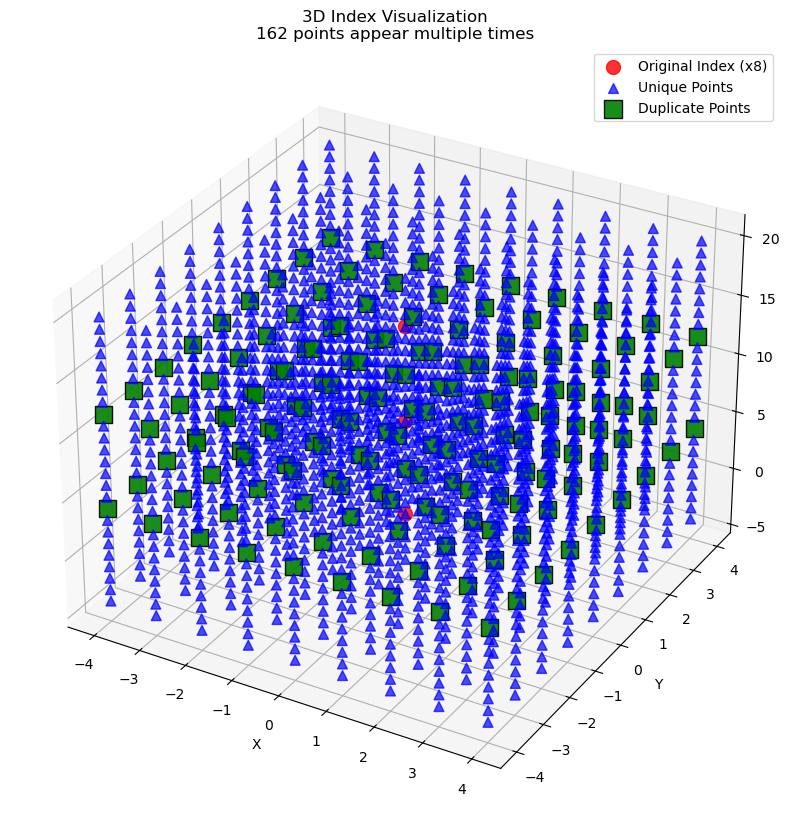

In [32]:
# plot the index and index 256 in 3d
import matplotlib.pyplot as plt

# Find unique indices and their counts
unique_indices, counts = np.unique(indexs_256, axis=0, return_counts=True)

# Separate unique and duplicate points
duplicates_mask = counts > 1
unique_points = unique_indices[~duplicates_mask]
duplicate_points = unique_indices[duplicates_mask]

print(f"Total points: {len(indexs_256)}")
print(f"Unique points: {len(unique_points)}")
print(f"Points that appear more than once: {len(duplicate_points)}")
print(f"Duplicate counts: {counts[duplicates_mask]}")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot original index points (scaled by 8)
ax.scatter(indexs2[:, 0]*8, indexs2[:, 1]*8, indexs2[:, 2]*8, 
           c='red', marker='o', s=100, label='Original Index (x8)', alpha=0.8)

# Plot unique points in blue
if len(unique_points) > 0:
    ax.scatter(unique_points[:, 0], unique_points[:, 1], unique_points[:, 2], 
               c='blue', marker='^', s=50, label='Unique Points', alpha=0.7)

# Plot duplicate points in green with larger size
if len(duplicate_points) > 0:
    ax.scatter(duplicate_points[:, 0], duplicate_points[:, 1], duplicate_points[:, 2], 
               c='green', marker='s', s=150, label='Duplicate Points', alpha=0.9, edgecolors='black')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
ax.set_title(f'3D Index Visualization\n{len(duplicate_points)} points appear multiple times')
plt.show()

In [ ]:
# Create 3D array of shape (129, 129, 129) with all values set to 1000
array_3d = np.full((129, 129, 129), 1000)
print(f"Shape: {array_3d.shape}")
print(f"All values are 1000: {np.all(array_3d == 1000)}")
print(f"Data type: {array_3d.dtype}")
print(f"Memory usage: {array_3d.nbytes / (1024**2):.2f} MB")